In [1]:
import pandas as pd
import utils as uti

In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,checking_account_status_woe,50.953937,0.228923,False
1,credit_history_woe,29.756816,0.414942,True
2,savings_account_bonds_woe,18.672573,0.228923,False
3,purpose_woe,17.780177,0.137224,False
4,duration_months_woe,15.856048,0.181447,False


## load info from previous steps

In [5]:
event = 'bad'

In [6]:
woe_vars = walds['var'].tolist() 
raw_vars = [woe_vars.removesuffix("_woe") for woe_vars in woe_vars]
raw_vars

['checking_account_status',
 'credit_history',
 'savings_account_bonds',
 'purpose',
 'duration_months',
 'employment_since',
 'housing',
 'other_installment_plans',
 'property',
 'credit_amount',
 'installment_rate_percent',
 'telephone',
 'existing_credits_at_bank',
 'residence_since']

In [7]:
X = df[raw_vars]
y = df[event]

In [8]:
import numpy as np
import optuna
import toad

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "n_estimators": 3000,
    
        "max_depth": trial.suggest_int("max_depth", 2, 5),
    
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.25, log=True
        ),
    
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1.0, 30.0, log=True
        ),
    
        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),
    
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),
    
        "gamma": trial.suggest_float(
            "gamma", 1e-6, 5.0, log=True
        ),
    
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 10.0, log=True
        ),
    
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1.0, 100.0, log=True
        ),
    
        "random_state": 42,
        "n_jobs": -1,
        "early_stopping_rounds": 100,
    }


    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        # Fit bins only on this fold's training data
        combiner = toad.transform.Combiner()

        combiner.fit(
            X_fold_train,
            y=y_fold_train,
            method="chi",
            min_samples=0.05
        )

        # Transform both sets using training-fold bin rules
        X_fold_train_bins = combiner.transform(X_fold_train)
        X_fold_valid_bins = combiner.transform(X_fold_valid)

        # Fit WoE only on this fold's training bins
        woe = toad.transform.WOETransformer()

        woe.fit(
            X_fold_train_bins,
            y_fold_train
        )

        # Transform validation data using training-fold WoE mappings
        X_fold_train_woe = woe.transform(X_fold_train_bins)
        X_fold_valid_woe = woe.transform(X_fold_valid_bins)


        # add suffix


        X_fold_train_woe = X_fold_train_woe.add_suffix("_woe")
        X_fold_valid_woe = X_fold_valid_woe.add_suffix("_woe")

        model = XGBClassifier(**params)

        model.fit(
            X_fold_train_woe,
            y_fold_train,
            eval_set=[(X_fold_valid_woe, y_fold_valid)],
            verbose=False
        )

        valid_probabilities = model.predict_proba(
            X_fold_valid_woe
        )[:, 1]

        fold_auc = roc_auc_score(
            y_fold_valid,
            valid_probabilities
        )

        fold_scores.append(fold_auc)

        # Optional pruning during the Optuna trial
        trial.report(np.mean(fold_scores), step=fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


In [9]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=250,
    show_progress_bar=True
)

[I 2026-09-11 21:04:45,234] A new study created in memory with name: no-name-a04bdca3-3643-4c84-be7c-d1684dc6074f


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-09-11 21:04:45,724] Trial 0 finished with value: 0.7692857142857144 and parameters: {'max_depth': 3, 'learning_rate': 0.2133249073808361, 'min_child_weight': 12.057126287443763, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'gamma': 1.1091814877139725e-05, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 53.99484409787433}. Best is trial 0 with value: 0.7692857142857144.
[I 2026-09-11 21:04:46,048] Trial 1 finished with value: 0.7673809523809523 and parameters: {'max_depth': 4, 'learning_rate': 0.09768839753070749, 'min_child_weight': 1.0725209743171995, 'subsample': 0.9909729556485982, 'colsample_bytree': 0.9497327922401265, 'gamma': 2.6451684446721577e-05, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 2.32706770838378}. Best is trial 0 with value: 0.7692857142857144.
[I 2026-09-11 21:04:46,363] Trial 2 finished with value: 0.7850476190476191 and parameters: {'max_depth': 3, 'learning_rate': 0.05414745020542119, 'min_child_weight': 4.3454541097

In [10]:
print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

Best AUC: 0.7997142857142857
Best parameters:
{'max_depth': 3, 'learning_rate': 0.10162406008901824, 'min_child_weight': 3.582357860303052, 'subsample': 0.7392404530563571, 'colsample_bytree': 0.8261937960243363, 'gamma': 2.0803290572724848e-05, 'reg_alpha': 0.00013979904260071304, 'reg_lambda': 9.394589164371187}


## optimization summary

In [11]:
import matplotlib.pyplot as plt

In [12]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_2482974/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


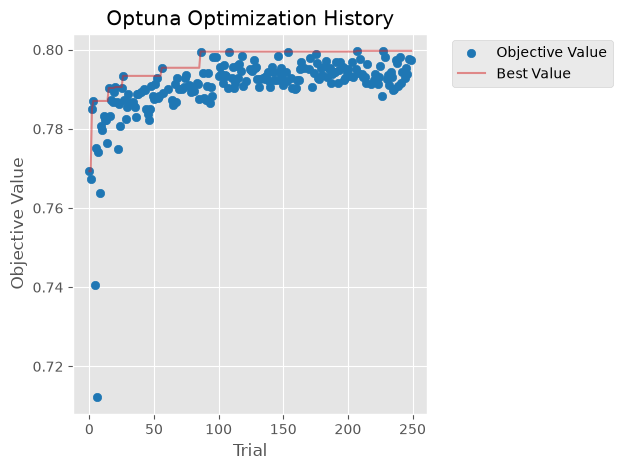

In [13]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2482974/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


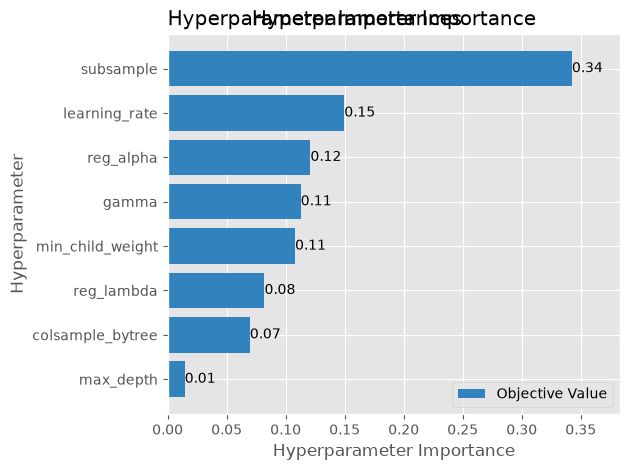

In [14]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2482974/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_2482974/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


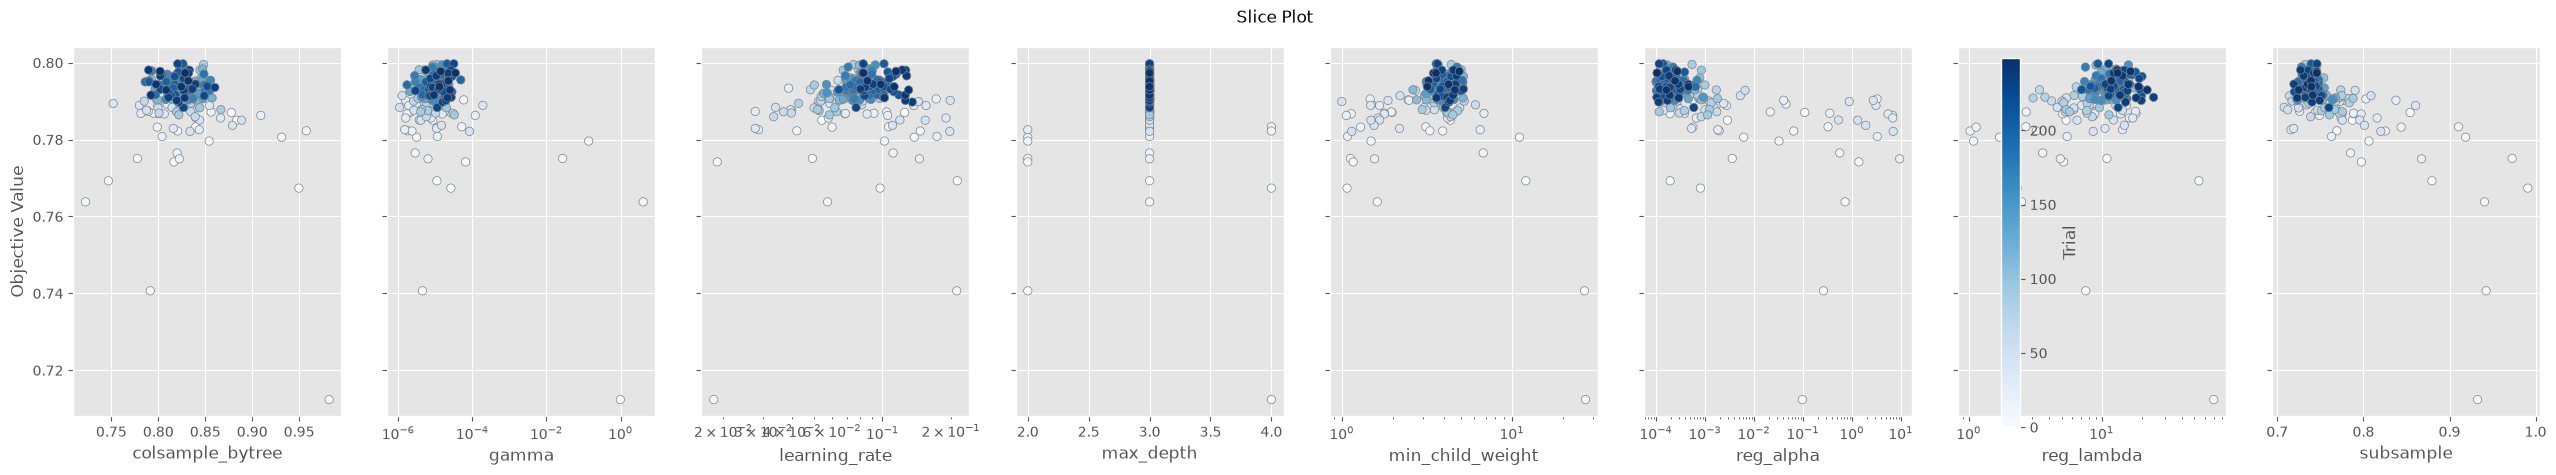

In [15]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2482974/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


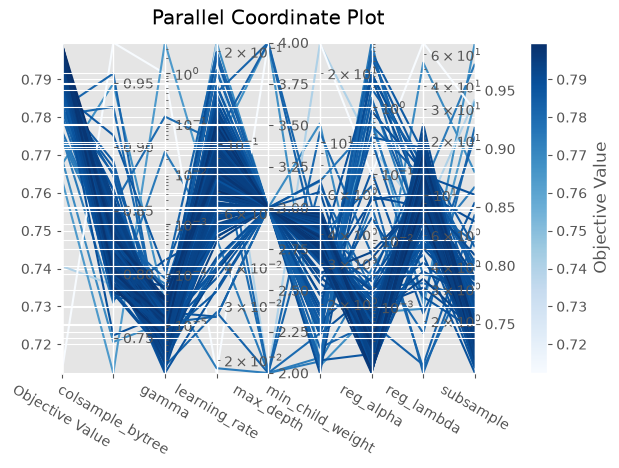

In [16]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2482974/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


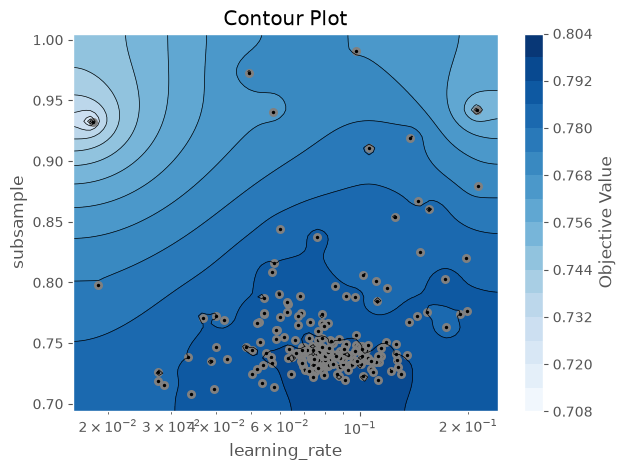

In [17]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [18]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [19]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_tpe:relative_params:0,state
227,227,0.799714,2026-09-11 21:06:05.039805,2026-09-11 21:06:05.385380,0 days 00:00:00.345575,0.820580,0.000032,0.082396,3,3.646074,0.000116,11.284307,0.745957,"{""colsample_bytree"": 0.8205800216008045, ""gamm...",COMPLETE
207,207,0.799714,2026-09-11 21:05:58.514974,2026-09-11 21:05:58.924248,0 days 00:00:00.409274,0.826194,0.000021,0.101624,3,3.582358,0.000140,9.394589,0.739240,"{""colsample_bytree"": 0.8261937960243363, ""gamm...",COMPLETE
86,86,0.799524,2026-09-11 21:05:16.235998,2026-09-11 21:05:16.562576,0 days 00:00:00.326578,0.848211,0.000011,0.074672,3,4.395509,0.000547,9.239254,0.732395,"{""colsample_bytree"": 0.8482110240488047, ""gamm...",COMPLETE
154,154,0.799429,2026-09-11 21:05:38.963954,2026-09-11 21:05:41.521346,0 days 00:00:02.557392,0.825099,0.000015,0.093058,3,3.638275,0.000147,15.917428,0.740533,"{""colsample_bytree"": 0.8250990493066332, ""gamm...",COMPLETE
108,108,0.799381,2026-09-11 21:05:23.553635,2026-09-11 21:05:23.878967,0 days 00:00:00.325332,0.821986,0.000009,0.079217,3,3.699590,0.000171,9.085064,0.745868,"{""colsample_bytree"": 0.8219863440850854, ""gamm...",COMPLETE
175,175,0.798857,2026-09-11 21:05:47.574565,2026-09-11 21:05:47.899504,0 days 00:00:00.324939,0.826873,0.000009,0.070695,3,4.759520,0.000224,7.554312,0.727979,"{""colsample_bytree"": 0.8268732494993645, ""gamm...",COMPLETE
118,118,0.798381,2026-09-11 21:05:26.945471,2026-09-11 21:05:27.428932,0 days 00:00:00.483461,0.847222,0.000008,0.087879,3,4.786582,0.000168,10.775087,0.730452,"{""colsample_bytree"": 0.8472219308444009, ""gamm...",COMPLETE
146,146,0.798333,2026-09-11 21:05:36.149608,2026-09-11 21:05:36.485914,0 days 00:00:00.336306,0.829241,0.000017,0.086282,3,3.723316,0.000162,12.885545,0.740942,"{""colsample_bytree"": 0.8292409101572493, ""gamm...",COMPLETE
98,98,0.798143,2026-09-11 21:05:20.108869,2026-09-11 21:05:20.467588,0 days 00:00:00.358719,0.827339,0.000004,0.078673,3,5.029423,0.000122,11.460700,0.735875,"{""colsample_bytree"": 0.8273393276288281, ""gamm...",COMPLETE
240,240,0.798095,2026-09-11 21:06:09.556395,2026-09-11 21:06:09.865220,0 days 00:00:00.308825,0.789632,0.000006,0.122064,3,4.529326,0.000253,13.048753,0.727050,"{""colsample_bytree"": 0.7896322964645196, ""gamm...",COMPLETE


# fit best model

In [20]:
# use woe from entire training data
X = df[woe_vars]

In [21]:
# from xgboost import XGBClassifier

best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = XGBClassifier(**best_params)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8261937960243363
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

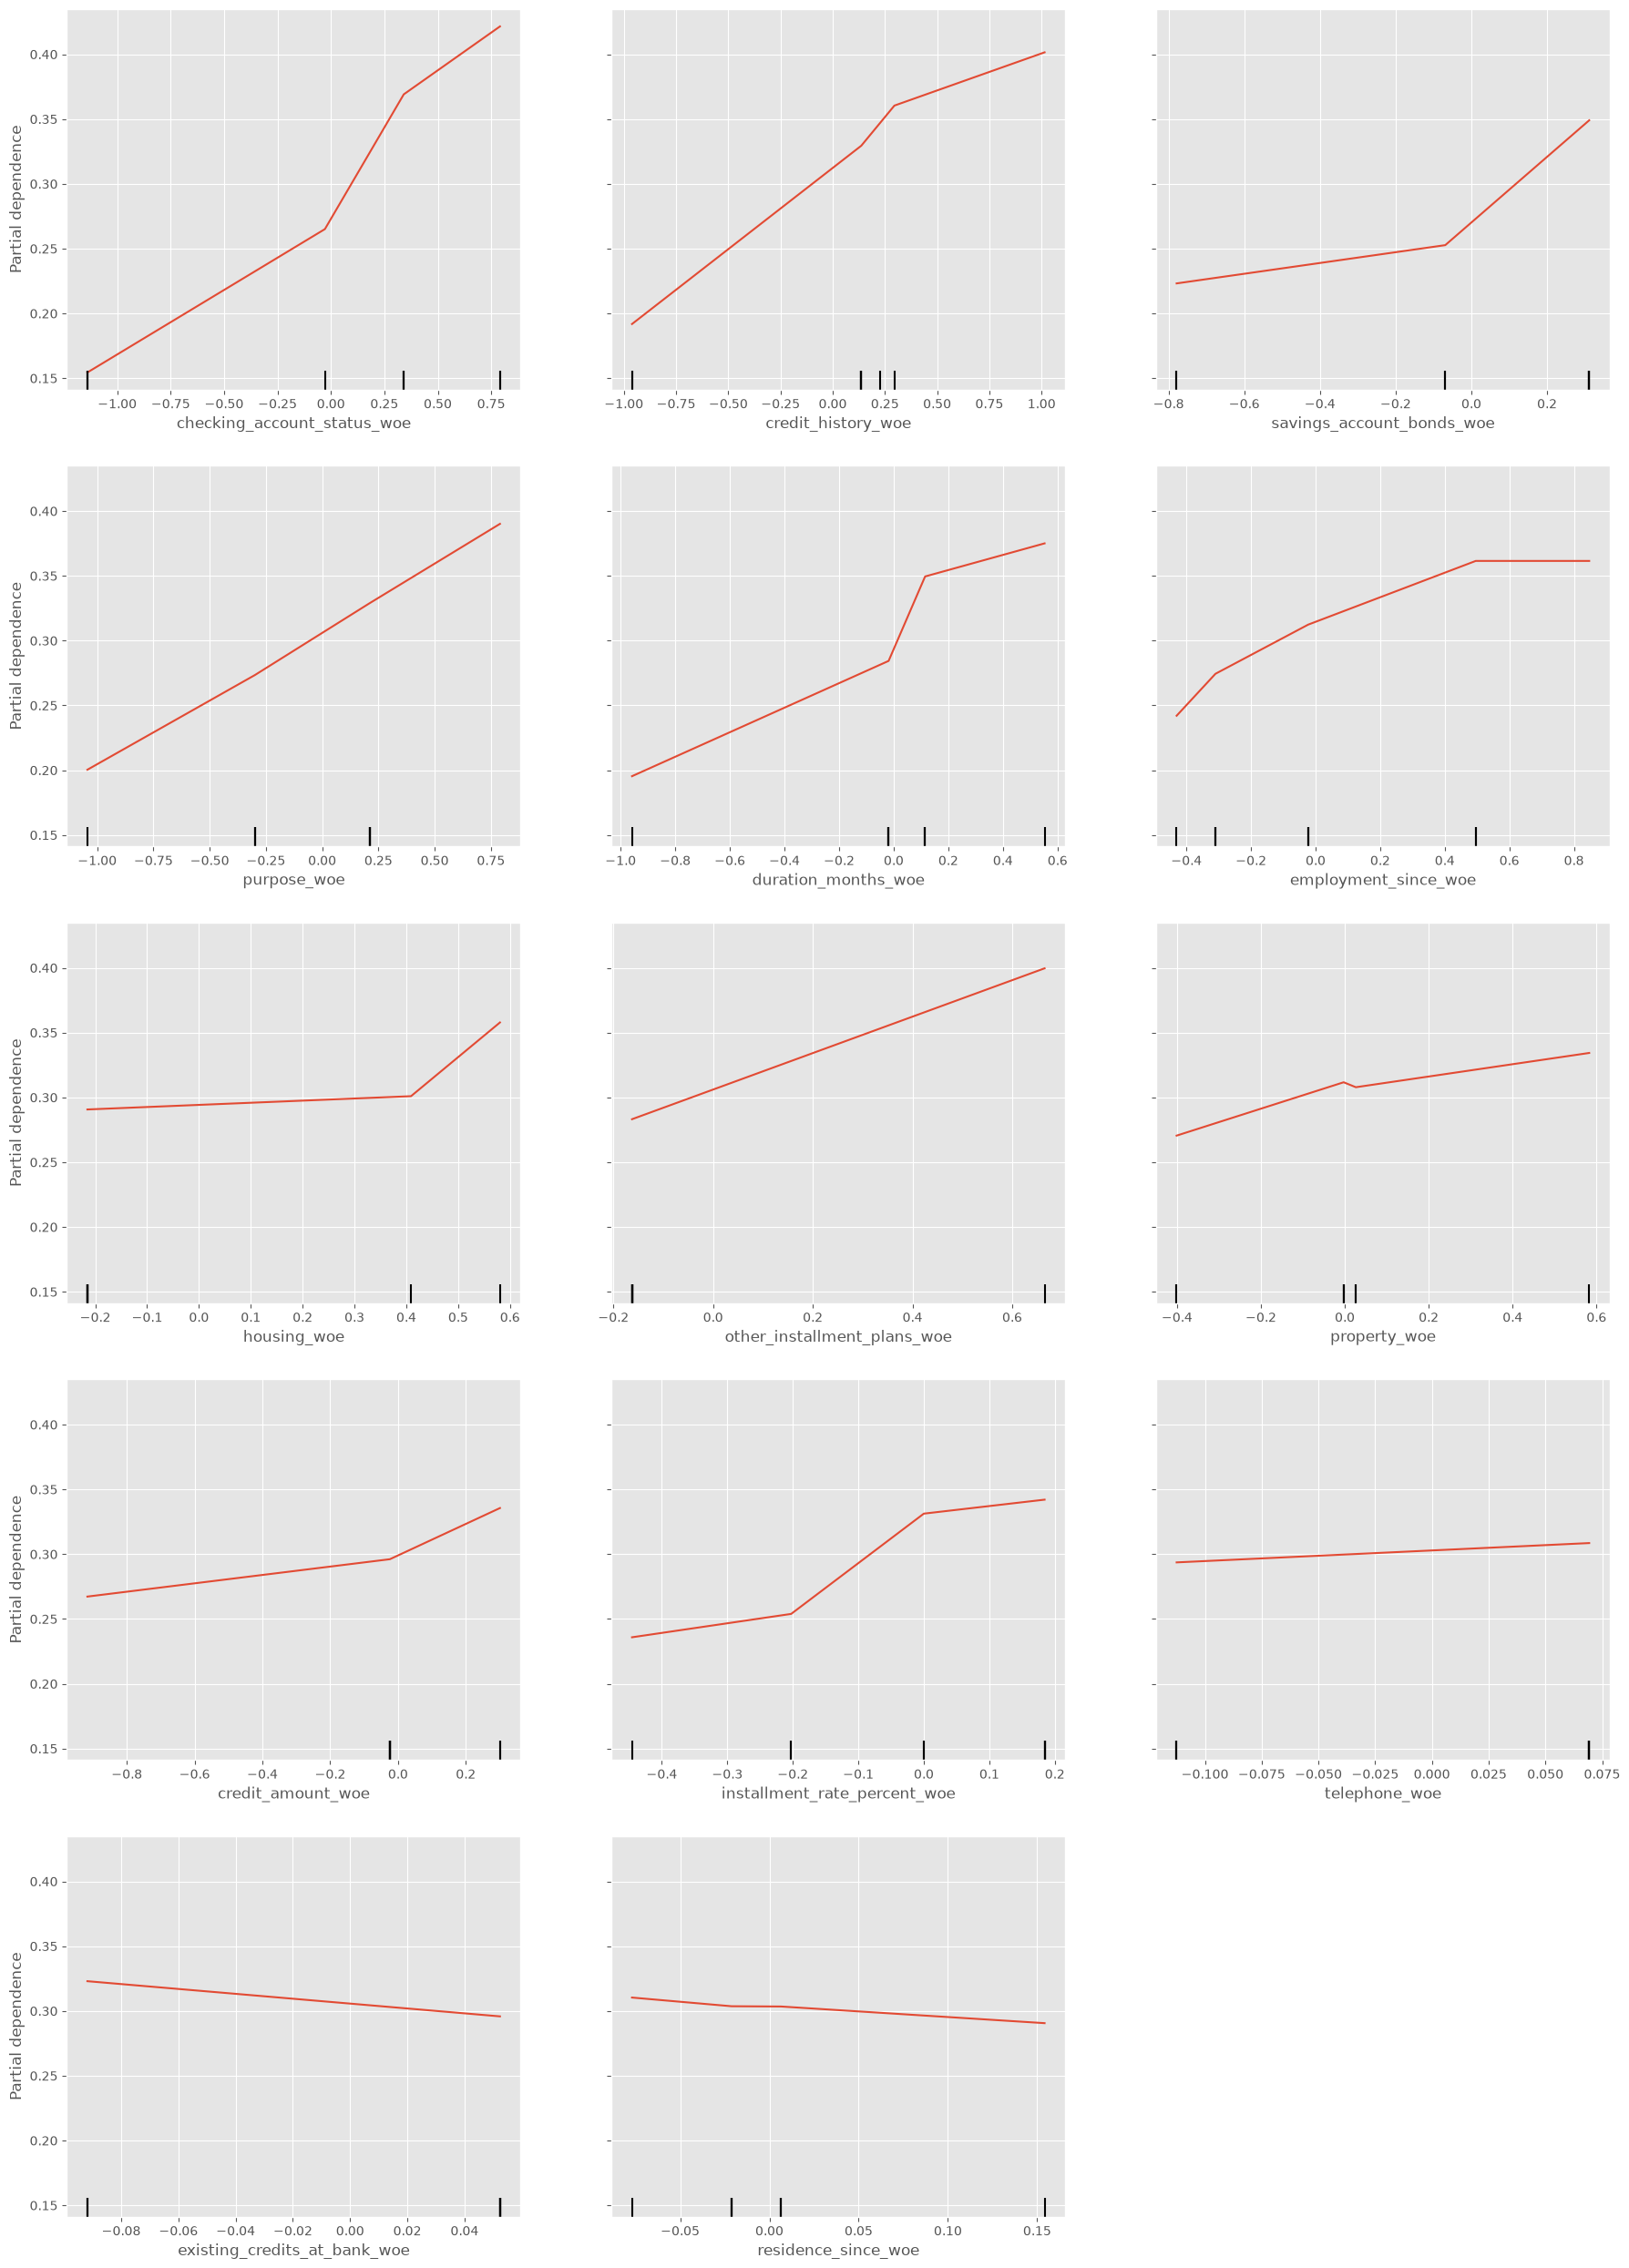

In [22]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = walds["var"].tolist()

display = PartialDependenceDisplay.from_estimator(
    final_model,
    X,
    features=features,
    n_cols=3
)

n_rows = (len(features) + 2) // 3

display.figure_.set_size_inches(
    18,
    5 * n_rows
)

display.figure_.tight_layout()

plt.show()

# save models

In [23]:
models['xgb woe'] = final_model

In [24]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)